<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reactions/Methanol_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Methanol production from natural gas with NeqSim

**Audience.** Process, chemical, energy, and production engineers who want a transparent equilibrium-based methanol-process workflow.

**Prerequisites.** Basic reaction stoichiometry, phase equilibrium, steady-state balances, SI units, and introductory Python. No previous NeqSim experience is required.

**Learning objectives.** By the end, you will be able to:

1. explain steam-methane reforming, water-gas shift, and methanol synthesis;
2. construct reacting fluids and solve isothermal Gibbs-equilibrium reactors;
3. verify carbon, hydrogen, oxygen, mass, and energy balances;
4. interpret temperature, pressure, and steam-to-carbon sensitivities;
5. connect reactors, cooling, separation, and compression in a `ProcessSystem`;
6. transfer reactor composition from SRK to CPA for methanol-water condensation;
7. calculate product recovery, utility indicators, and an idealized recycle limit; and
8. identify what an equilibrium tutorial omits from industrial reactor design.

This is an educational screening model, not a licensed technology design, catalyst guarantee, emissions inventory, or plant performance test.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim",
        ]
    )

## 1. Scope, basis, and units

The notebook follows this calculation chain:

`reacting fluid -> Gibbs equilibrium -> balances -> process units -> CPA product flash -> checks`

The feed is a methane surrogate for desulfurized natural gas. The base reformer receives 20,000 kg/h at 1123.15 K and 25 bara with a steam-to-carbon molar ratio of 3. The synthesis reactor operates at 523.15 K and 80 bara. Product condensation is screened at 308.15 K.

Pressure is absolute. Temperatures are in K; pressure in bara; flow in kg/h; power and heat duty in kW; composition and conversion are molar fractions. Values are reproducible educational inputs, not claimed optimums.

In [2]:
from importlib.metadata import version
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim


NEQSIM_VERSION = version("neqsim")
REFORMER_PRESSURE_BARA = 25.0
REFORMER_TEMPERATURE_K = 1123.15
STEAM_TO_CARBON_RATIO = 3.0
SYNTHESIS_PRESSURE_BARA = 80.0
SYNTHESIS_TEMPERATURE_K = 523.15
PRODUCT_TEMPERATURE_K = 308.15
FEED_FLOW_KG_PER_H = 20000.0

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

print(f"NeqSim version [-]: {NEQSIM_VERSION}")
print("All pressures are absolute and all displayed quantities are SI-labelled.")

NeqSim version [-]: 3.16.0
All pressures are absolute and all displayed quantities are SI-labelled.


## 2. Governing reactions and equilibrium

Steam-methane reforming is strongly endothermic:

$$
\mathrm{CH_4 + H_2O \rightleftharpoons CO + 3H_2}
$$

Water-gas shift redistributes carbon monoxide, carbon dioxide, hydrogen, and steam:

$$
\mathrm{CO + H_2O \rightleftharpoons CO_2 + H_2}
$$

The main synthesis routes are:

$$
\mathrm{CO + 2H_2 \rightleftharpoons CH_3OH}
$$

$$
\mathrm{CO_2 + 3H_2 \rightleftharpoons CH_3OH + H_2O}
$$

At fixed temperature and pressure, an equilibrium state minimizes Gibbs energy while conserving each chemical element. A real catalyst changes reaction rate and selectivity, but not the final thermodynamic equilibrium state.

In [3]:
ATOM_MATRIX = {
    "methane": {"C": 1.0, "H": 4.0},
    "water": {"H": 2.0, "O": 1.0},
    "hydrogen": {"H": 2.0},
    "CO": {"C": 1.0, "O": 1.0},
    "CO2": {"C": 1.0, "O": 2.0},
    "methanol": {"C": 1.0, "H": 4.0, "O": 1.0},
}


def component_moles(fluid):
    totals = {}

    for phase_index in range(fluid.getNumberOfPhases()):
        phase = fluid.getPhase(phase_index)

        for component_index in range(fluid.getNumberOfComponents()):
            component = phase.getComponent(component_index)
            name = str(component.getComponentName())
            phase_moles = component.getNumberOfMolesInPhase()
            totals[name] = totals.get(name, 0.0) + phase_moles

    return totals


def element_totals(mole_inventory):
    totals = {"C": 0.0, "H": 0.0, "O": 0.0}

    for component_name, moles in mole_inventory.items():
        for element_name, atom_count in ATOM_MATRIX[component_name].items():
            totals[element_name] += moles * atom_count

    return totals

## 3. How NeqSim represents reacting fluids and process units

A NeqSim thermodynamic system contains an equation of state, component inventory, temperature, pressure, phases, and calculation settings. `SystemSrkEos` is used for the hot reformer and synthesis gas because these states are gas-rich and cubic equations are established screening models there.

`GibbsReactor` changes species amounts while preserving elements. Isothermal mode means an external heat duty is implied to hold the specified temperature. A `Stream` adds a flow rate and a named connection. `Cooler`, `Separator`, and `Compressor` transform or route that stream, while `ProcessSystem` executes units in order.

Tiny seed amounts of possible products make all reacting species available to the Gibbs solver. They are explicit numerical seeds, not feed impurities and not fitted parameters.

In [4]:
def create_reformer_fluid(temperature_k, pressure_bara, steam_to_carbon):
    fluid = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    fluid.addComponent("methane", 1.0)
    fluid.addComponent("water", steam_to_carbon)
    fluid.addComponent("hydrogen", 1.0e-8)
    fluid.addComponent("CO", 1.0e-8)
    fluid.addComponent("CO2", 1.0e-8)
    fluid.addComponent("methanol", 1.0e-8)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


base_reformer_fluid = create_reformer_fluid(
    REFORMER_TEMPERATURE_K,
    REFORMER_PRESSURE_BARA,
    STEAM_TO_CARBON_RATIO,
)
base_reformer_inventory = component_moles(base_reformer_fluid)
base_reformer_table = pd.Series(
    base_reformer_inventory,
    name="initial component moles on the unscaled fluid basis [mol]",
)
base_reformer_table

methane    2.000000
water      6.000000
hydrogen   0.000000
CO         0.000000
CO2        0.000000
methanol   0.000000
Name: initial component moles on the unscaled fluid basis [mol], dtype: float64

## 4. Reusable Gibbs-reactor workflow

The helper creates a named inlet stream, attaches an isothermal Gibbs reactor, and runs both through a process system. No exception is swallowed: a solver failure stops execution and remains visible.

For an isothermal steady reactor with negligible kinetic and potential energy changes and no shaft work:

$$
\dot Q = \dot m\left(h_{\mathrm{out}}-h_{\mathrm{in}}\right)
$$

$\dot Q$ is heat duty in kW, $\dot m$ is mass flow in kg/s, and $h$ is specific enthalpy in kJ/kg. Positive duty means heat must enter the reactor; negative duty means heat must be removed.

In [5]:
def run_gibbs_reactor(
    name,
    fluid,
    flow_rate_kg_per_h,
    inert_components=None,
):
    feed_stream = jneqsim.process.equipment.stream.Stream(
        f"{name} feed",
        fluid,
    )
    feed_stream.setFlowRate(flow_rate_kg_per_h, "kg/hr")

    reactor = jneqsim.process.equipment.reactor.GibbsReactor(
        name,
        feed_stream,
    )
    reactor.setEnergyMode("isothermal")
    reactor.setMaxIterations(5000)

    for component_name in inert_components or []:
        reactor.setComponentAsInert(component_name)

    process = jneqsim.process.processmodel.ProcessSystem()
    process.add(feed_stream)
    process.add(reactor)
    process.run()
    return feed_stream, reactor


def isothermal_reactor_duty_kw(feed_stream, reactor):
    feed_enthalpy = feed_stream.getFluid().getEnthalpy("kJ/kg")
    outlet_enthalpy = reactor.getOutletStream().getFluid().getEnthalpy("kJ/kg")
    mass_flow_kg_per_s = feed_stream.getFlowRate("kg/hr") / 3600.0
    return mass_flow_kg_per_s * (outlet_enthalpy - feed_enthalpy)


smr_feed_stream, smr_reactor = run_gibbs_reactor(
    "steam methane reformer",
    base_reformer_fluid,
    FEED_FLOW_KG_PER_H,
)
print("Base reformer equilibrium calculation completed.")

Base reformer equilibrium calculation completed.


## 5. Reformer conversion, syngas quality, and balances

Methane conversion is calculated from component moles, not mole-fraction change:

$$
X_{\mathrm{CH_4}} = 1-\frac{n_{\mathrm{CH_4,out}}}{n_{\mathrm{CH_4,in}}}
$$

The synthesis stoichiometric number is commonly screened as:

$$
S_N = \frac{n_{\mathrm{H_2}}-n_{\mathrm{CO_2}}}{n_{\mathrm{CO}}+n_{\mathrm{CO_2}}}
$$

An $S_N$ near 2 is useful for methanol synthesis, although a licensed process uses a more detailed definition and constraints. The atom table independently checks carbon, hydrogen, and oxygen conservation.

In [6]:
smr_inlet_moles = component_moles(smr_feed_stream.getFluid())
smr_outlet_fluid = smr_reactor.getOutletStream().getFluid()
smr_outlet_moles = component_moles(smr_outlet_fluid)
smr_conversion = 1.0 - (
    smr_outlet_moles["methane"] / smr_inlet_moles["methane"]
)
smr_stoichiometric_number = (
    smr_outlet_moles["hydrogen"] - smr_outlet_moles["CO2"]
) / (smr_outlet_moles["CO"] + smr_outlet_moles["CO2"])
smr_duty_kw = isothermal_reactor_duty_kw(smr_feed_stream, smr_reactor)

smr_element_in = element_totals(smr_inlet_moles)
smr_element_out = element_totals(smr_outlet_moles)
smr_element_residuals = {
    element: (smr_element_out[element] / smr_element_in[element] - 1.0)
    for element in smr_element_in
}

smr_results = pd.Series(
    {
        "methane conversion [-]": smr_conversion,
        "stoichiometric number [-]": smr_stoichiometric_number,
        "isothermal reformer duty [kW]": smr_duty_kw,
        "maximum atom residual [-]": max(
            abs(value) for value in smr_element_residuals.values()
        ),
    },
    name="Base reformer results",
)

print(smr_results.to_string())
pd.DataFrame(
    {
        "inlet atoms [mol]": smr_element_in,
        "outlet atoms [mol]": smr_element_out,
        "relative residual [-]": smr_element_residuals,
    }
)

methane conversion [-]              0.792984
stoichiometric number [-]           3.000000
isothermal reformer duty [kW]   1,519.559927
maximum atom residual [-]           0.000000


,inlet atoms [mol],outlet atoms [mol],relative residual [-]
C,79.265433,79.265433,0.000000
H,792.654307,792.654307,0.000000
O,237.796294,237.796294,0.000000


## 6. Reformer temperature sensitivity

The SMR reaction is endothermic, so equilibrium methane conversion should rise with temperature. The sweep covers 973.15-1173.15 K at 25 bara and steam-to-carbon ratio 3. The U.S. Department of Energy describes industrial steam reforming in the broad range 973-1273 K and 3-25 bar, so these values are plausible screening conditions.

Equilibrium does not describe furnace heat flux, tube-metal temperature, catalyst activity, pressure drop, methane slip from kinetics, carbon formation, or mechanical limits. Those must be added before design use.

In [7]:
reformer_temperatures_k = np.array(
    [973.15, 1023.15, 1073.15, 1123.15, 1173.15]
)
reformer_temperature_rows = []

for temperature_k in reformer_temperatures_k:
    sensitivity_fluid = create_reformer_fluid(
        temperature_k,
        REFORMER_PRESSURE_BARA,
        STEAM_TO_CARBON_RATIO,
    )
    sensitivity_feed, sensitivity_reactor = run_gibbs_reactor(
        "reformer temperature case",
        sensitivity_fluid,
        1000.0,
    )
    inlet_moles = component_moles(sensitivity_feed.getFluid())
    outlet_moles = component_moles(
        sensitivity_reactor.getOutletStream().getFluid()
    )
    methane_conversion = 1.0 - (
        outlet_moles["methane"] / inlet_moles["methane"]
    )
    reformer_temperature_rows.append(
        {
            "temperature [K]": temperature_k,
            "methane conversion [-]": methane_conversion,
        }
    )

reformer_temperature_table = pd.DataFrame(reformer_temperature_rows)
reformer_temperature_table

,temperature [K],methane conversion [-]
0,973.150000,0.436827
1,"1,023.150000",0.553601
2,"1,073.150000",0.677416
3,"1,123.150000",0.792924
4,"1,173.150000",0.883211


## 7. Steam-to-carbon sensitivity

Extra steam shifts reforming and water-gas-shift equilibria, increases methane conversion, and reduces carbon-deposition risk in real operation. It also increases furnace duty, steam generation, equipment size, and downstream water removal.

The sweep therefore illustrates a trade-off rather than an optimization. `GibbsReactor` includes only the listed gas-phase species; solid carbon is not included, so this notebook cannot calculate a carbon-free operating boundary.

In [8]:
steam_to_carbon_values = np.array([2.0, 2.5, 3.0, 3.5, 4.0])
steam_ratio_rows = []

for steam_to_carbon in steam_to_carbon_values:
    sensitivity_fluid = create_reformer_fluid(
        REFORMER_TEMPERATURE_K,
        REFORMER_PRESSURE_BARA,
        steam_to_carbon,
    )
    sensitivity_feed, sensitivity_reactor = run_gibbs_reactor(
        "steam ratio case",
        sensitivity_fluid,
        1000.0,
    )
    inlet_moles = component_moles(sensitivity_feed.getFluid())
    outlet_moles = component_moles(
        sensitivity_reactor.getOutletStream().getFluid()
    )
    conversion = 1.0 - outlet_moles["methane"] / inlet_moles["methane"]
    stoichiometric_number = (
        outlet_moles["hydrogen"] - outlet_moles["CO2"]
    ) / (outlet_moles["CO"] + outlet_moles["CO2"])
    steam_ratio_rows.append(
        {
            "steam-to-carbon ratio [-]": steam_to_carbon,
            "methane conversion [-]": conversion,
            "stoichiometric number [-]": stoichiometric_number,
        }
    )

steam_ratio_table = pd.DataFrame(steam_ratio_rows)
steam_ratio_table

,steam-to-carbon ratio [-],methane conversion [-],stoichiometric number [-]
0,2.000000,0.677031,3.000000
1,2.500000,0.741657,3.000000
2,3.000000,0.792924,3.000000
3,3.500000,0.833707,3.000000
4,4.000000,0.866141,3.000000


## 8. Methanol-synthesis feed and equilibrium

The independent synthesis example uses $n_{\mathrm{H_2}}/n_{\mathrm{CO}}=2.1$, 5 mol% carbon dioxide relative to carbon monoxide, and a small methane inert. Methane is explicitly marked inert in the synthesis reactor so the solver does not use it as a reforming reactant.

Methanol formation reduces the number of gas moles, so higher pressure favors equilibrium conversion. The synthesis reactions are exothermic, so lower temperature favors equilibrium but slows catalyst kinetics. Industrial operation balances equilibrium, kinetics, heat removal, catalyst stability, and recycle.

In [9]:
def create_synthesis_fluid(temperature_k, pressure_bara):
    fluid = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    fluid.addComponent("hydrogen", 2.1)
    fluid.addComponent("CO", 1.0)
    fluid.addComponent("CO2", 0.05)
    fluid.addComponent("methanol", 1.0e-8)
    fluid.addComponent("water", 1.0e-8)
    fluid.addComponent("methane", 0.05)
    fluid.setMixingRule("classic")
    return fluid


base_synthesis_fluid = create_synthesis_fluid(
    SYNTHESIS_TEMPERATURE_K,
    SYNTHESIS_PRESSURE_BARA,
)
synthesis_feed_stream, synthesis_reactor = run_gibbs_reactor(
    "methanol synthesis reactor",
    base_synthesis_fluid,
    10000.0,
    inert_components=["methane"],
)
print("Base methanol-synthesis equilibrium calculation completed.")

Base methanol-synthesis equilibrium calculation completed.


## 9. Synthesis conversion, heat removal, and element closure

Carbon-oxide conversion to methanol is defined on a carbon basis:

$$
X_{\mathrm{MeOH,C}} = \frac{n_{\mathrm{MeOH,out}}-n_{\mathrm{MeOH,in}}}{n_{\mathrm{CO,in}}+n_{\mathrm{CO_2,in}}}
$$

This metric counts one carbon atom per carbon monoxide, carbon dioxide, and methanol molecule. The negative isothermal duty indicates heat removal. An industrial reactor would limit temperature rise and use boiling-water, quench, or staged cooling arrangements depending on technology.

In [10]:
synthesis_inlet_moles = component_moles(synthesis_feed_stream.getFluid())
synthesis_outlet_fluid = synthesis_reactor.getOutletStream().getFluid()
synthesis_outlet_moles = component_moles(synthesis_outlet_fluid)
carbon_oxide_feed = (
    synthesis_inlet_moles["CO"] + synthesis_inlet_moles["CO2"]
)
methanol_formed = (
    synthesis_outlet_moles["methanol"]
    - synthesis_inlet_moles["methanol"]
)
synthesis_carbon_conversion = methanol_formed / carbon_oxide_feed
synthesis_duty_kw = isothermal_reactor_duty_kw(
    synthesis_feed_stream,
    synthesis_reactor,
)
synthesis_element_in = element_totals(synthesis_inlet_moles)
synthesis_element_out = element_totals(synthesis_outlet_moles)
synthesis_element_residuals = {
    element: synthesis_element_out[element] / synthesis_element_in[element] - 1.0
    for element in synthesis_element_in
}

synthesis_results = pd.Series(
    {
        "carbon conversion to methanol [-]": synthesis_carbon_conversion,
        "isothermal synthesis duty [kW]": synthesis_duty_kw,
        "methanol formed [mol on scaled stream basis]": methanol_formed,
        "maximum atom residual [-]": max(
            abs(value) for value in synthesis_element_residuals.values()
        ),
    },
    name="Base synthesis results",
)
synthesis_results

carbon conversion to methanol [-]                 0.633247
isothermal synthesis duty [kW]                 -607.268972
methanol formed [mol on scaled stream basis]     52.400428
maximum atom residual [-]                         0.000000
Name: Base synthesis results, dtype: float64

## 10. Synthesis temperature and pressure sensitivities

The temperature sweep is at 80 bara; the pressure sweep is at 523.15 K. Equilibrium conversion should decrease with temperature and increase with pressure.

These are not catalyst-performance curves. A Gibbs reactor assumes sufficient time to reach equilibrium, permits all listed reactions, and does not represent rate expressions, catalyst volume, diffusion, deactivation, by-products, or reactor temperature profiles.

In [11]:
def synthesis_conversion(temperature_k, pressure_bara):
    fluid = create_synthesis_fluid(temperature_k, pressure_bara)
    feed_stream, reactor = run_gibbs_reactor(
        "synthesis sensitivity case",
        fluid,
        1000.0,
        inert_components=["methane"],
    )
    inlet_moles = component_moles(feed_stream.getFluid())
    outlet_moles = component_moles(reactor.getOutletStream().getFluid())
    carbon_oxide_moles = inlet_moles["CO"] + inlet_moles["CO2"]
    produced_methanol = outlet_moles["methanol"] - inlet_moles["methanol"]
    return produced_methanol / carbon_oxide_moles


synthesis_temperatures_k = np.array(
    [473.15, 498.15, 523.15, 548.15, 573.15]
)
synthesis_pressures_bara = np.array([40.0, 60.0, 80.0, 100.0, 120.0])
temperature_conversions = [
    synthesis_conversion(temperature_k, SYNTHESIS_PRESSURE_BARA)
    for temperature_k in synthesis_temperatures_k
]
pressure_conversions = [
    synthesis_conversion(SYNTHESIS_TEMPERATURE_K, pressure_bara)
    for pressure_bara in synthesis_pressures_bara
]

synthesis_sensitivity_table = pd.DataFrame(
    {
        "temperature [K]": synthesis_temperatures_k,
        "temperature-sweep conversion [-]": temperature_conversions,
        "pressure [bara]": synthesis_pressures_bara,
        "pressure-sweep conversion [-]": pressure_conversions,
    }
)
synthesis_sensitivity_table

,temperature [K],temperature-sweep conversion [-],pressure [bara],pressure-sweep conversion [-]
0,473.150000,0.837954,40.000000,0.417046
1,498.150000,0.753574,60.000000,0.551096
2,523.150000,0.633205,80.000000,0.633205
3,548.150000,0.479124,100.000000,0.687798
4,573.150000,0.315539,120.000000,0.726630


## 11. Interpreting the equilibrium figures

The four panels separate the two reformer and two synthesis questions. Smooth monotonic results are numerical and physical checks. The reformer requires high temperature and steam; the synthesis loop benefits from lower temperature and higher pressure. That opposition is why heat recovery, compression, cooling, condensation, and recycle are central to the process.

Each curve changes only one variable. Simultaneous optimization must include energy, equipment, catalyst, carbon, reliability, and economic constraints.

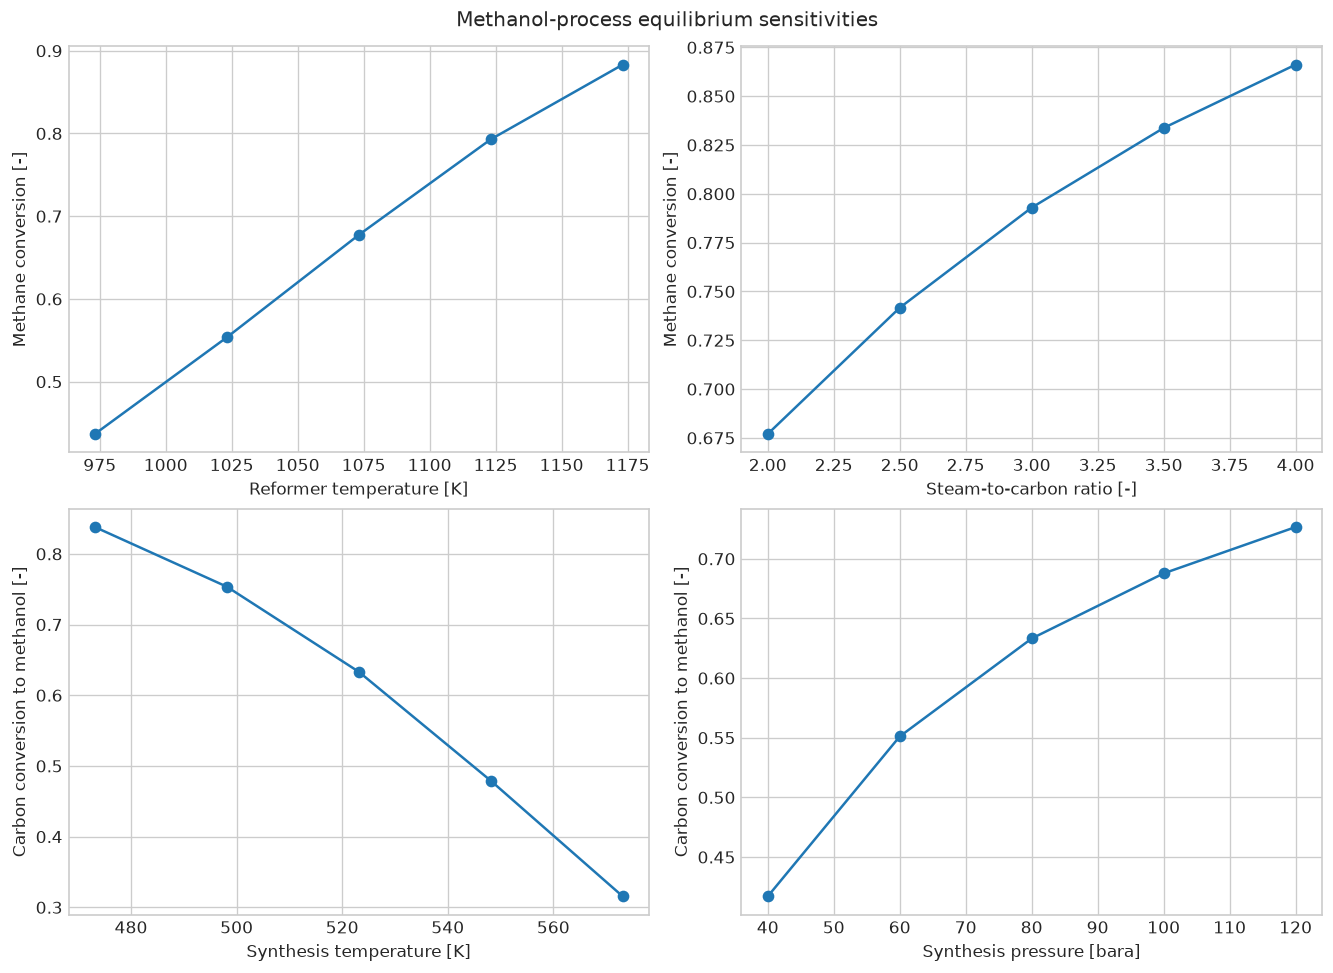

In [12]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(
    reformer_temperature_table["temperature [K]"],
    reformer_temperature_table["methane conversion [-]"],
    marker="o",
)
axes[0, 0].set_xlabel("Reformer temperature [K]")
axes[0, 0].set_ylabel("Methane conversion [-]")

axes[0, 1].plot(
    steam_ratio_table["steam-to-carbon ratio [-]"],
    steam_ratio_table["methane conversion [-]"],
    marker="o",
)
axes[0, 1].set_xlabel("Steam-to-carbon ratio [-]")
axes[0, 1].set_ylabel("Methane conversion [-]")

axes[1, 0].plot(
    synthesis_temperatures_k,
    temperature_conversions,
    marker="o",
)
axes[1, 0].set_xlabel("Synthesis temperature [K]")
axes[1, 0].set_ylabel("Carbon conversion to methanol [-]")

axes[1, 1].plot(
    synthesis_pressures_bara,
    pressure_conversions,
    marker="o",
)
axes[1, 1].set_xlabel("Synthesis pressure [bara]")
axes[1, 1].set_ylabel("Carbon conversion to methanol [-]")

figure.suptitle("Methanol-process equilibrium sensitivities")
plt.show()

## 12. Connected reforming and synthesis front end

The integrated process now connects:

1. methane and steam feed;
2. isothermal reformer;
3. syngas cooling and condensed-water removal;
4. compression from 25 to 80 bara at 78% isentropic efficiency;
5. cooling to 523.15 K; and
6. isothermal methanol synthesis with methane inert.

The water knockout protects the compressor and changes syngas composition. Named outlet streams make each state available to later equipment. Heat recovery is represented only by duty, not by a matched steam system or exchanger area.

In [13]:
integrated_fluid = create_reformer_fluid(
    REFORMER_TEMPERATURE_K,
    REFORMER_PRESSURE_BARA,
    STEAM_TO_CARBON_RATIO,
)
integrated_feed = jneqsim.process.equipment.stream.Stream(
    "integrated reformer feed",
    integrated_fluid,
)
integrated_feed.setFlowRate(FEED_FLOW_KG_PER_H, "kg/hr")

integrated_reformer = jneqsim.process.equipment.reactor.GibbsReactor(
    "integrated reformer",
    integrated_feed,
)
integrated_reformer.setEnergyMode("isothermal")
integrated_reformer.setMaxIterations(5000)

syngas_cooler = jneqsim.process.equipment.heatexchanger.Cooler(
    "syngas cooler",
    integrated_reformer.getOutletStream(),
)
syngas_cooler.setOutTemperature(313.15, "K")

water_separator = jneqsim.process.equipment.separator.Separator(
    "process-water knockout",
    syngas_cooler.getOutletStream(),
)

syngas_compressor = jneqsim.process.equipment.compressor.Compressor(
    "syngas compressor",
    water_separator.getGasOutStream(),
)
syngas_compressor.setOutletPressure(SYNTHESIS_PRESSURE_BARA, "bara")
syngas_compressor.setIsentropicEfficiency(0.78)

synthesis_feed_cooler = jneqsim.process.equipment.heatexchanger.Cooler(
    "synthesis feed cooler",
    syngas_compressor.getOutletStream(),
)
synthesis_feed_cooler.setOutTemperature(SYNTHESIS_TEMPERATURE_K, "K")

integrated_synthesis_reactor = jneqsim.process.equipment.reactor.GibbsReactor(
    "integrated methanol reactor",
    synthesis_feed_cooler.getOutletStream(),
)
integrated_synthesis_reactor.setEnergyMode("isothermal")
integrated_synthesis_reactor.setMaxIterations(5000)
integrated_synthesis_reactor.setComponentAsInert("methane")

integrated_process = jneqsim.process.processmodel.ProcessSystem()
integrated_units = [
    integrated_feed,
    integrated_reformer,
    syngas_cooler,
    water_separator,
    syngas_compressor,
    synthesis_feed_cooler,
    integrated_synthesis_reactor,
]

for unit in integrated_units:
    integrated_process.add(unit)

integrated_process.run()
print("Connected reforming and synthesis process completed.")

Connected reforming and synthesis process completed.


## 13. Process stream table and utility indicators

The table reports each named connection on a mass-flow basis. Phase count is checked rather than assumed. Compressor power is shaft power calculated by the compressor model. Reformer and synthesis heat duties are enthalpy differences required by isothermal equilibrium.

Small reactor mass residuals reflect Gibbs-solver tolerances and the finite seed species. Element balances are the stronger reaction check and close to floating-point precision. A design model would set explicit acceptable solver tolerances and reconcile every utility stream.

In [14]:
integrated_streams = {
    "reformer feed": integrated_feed,
    "reformed gas": integrated_reformer.getOutletStream(),
    "dry syngas": water_separator.getGasOutStream(),
    "synthesis feed": synthesis_feed_cooler.getOutletStream(),
    "reactor product": integrated_synthesis_reactor.getOutletStream(),
}
stream_rows = []

for stream_name, stream in integrated_streams.items():
    stream.run()
    fluid = stream.getFluid()
    stream_rows.append(
        {
            "stream": stream_name,
            "temperature [K]": fluid.getTemperature("K"),
            "pressure [bara]": fluid.getPressure("bara"),
            "mass flow [kg/h]": stream.getFlowRate("kg/hr"),
            "phase count [-]": fluid.getNumberOfPhases(),
        }
    )

integrated_stream_table = pd.DataFrame(stream_rows).set_index("stream")
integrated_reformer_duty_kw = isothermal_reactor_duty_kw(
    integrated_feed,
    integrated_reformer,
)
integrated_synthesis_duty_kw = isothermal_reactor_duty_kw(
    synthesis_feed_cooler.getOutletStream(),
    integrated_synthesis_reactor,
)
water_knockout_rate_kg_per_h = (
    water_separator.getLiquidOutStream().getFlowRate("kg/hr")
)
compressor_power_kw = syngas_compressor.getPower("kW")

utility_table = pd.Series(
    {
        "reformer heat input [kW]": integrated_reformer_duty_kw,
        "synthesis heat duty [kW]": integrated_synthesis_duty_kw,
        "syngas compressor power [kW]": compressor_power_kw,
        "knocked-out water-rich liquid [kg/h]": water_knockout_rate_kg_per_h,
    },
    name="Process indicators",
)

print(integrated_stream_table.to_string())
utility_table

                 temperature [K]  pressure [bara]  mass flow [kg/h]  phase count [-]
stream                                                                              
reformer feed       1,123.150000        25.000000     20,000.000000                1
reformed gas        1,123.150000        25.000000     20,000.226282                1
dry syngas            313.150000        25.000000     10,246.458648                1
synthesis feed        523.150000        80.000000     10,246.458648                1
reactor product       523.150000        80.000000     10,246.332041                2


reformer heat input [kW]               1,519.559927
synthesis heat duty [kW]                -389.713633
syngas compressor power [kW]           1,363.027040
knocked-out water-rich liquid [kg/h]   9,753.767634
Name: Process indicators, dtype: float64

## 14. Why the product condensation step changes model

SRK is retained for the hot reacting gas, but methanol and water associate through hydrogen bonding. The reactor outlet component amounts are therefore transferred explicitly into `SystemSrkCPAstatoil` for the 308.15 K product flash. This is a model handoff, not a change in material inventory.

CPA adds an association contribution to the cubic reference model:

$$
P = P_{\mathrm{SRK}} + P_{\mathrm{assoc}}
$$

The TP flash then partitions the fixed overall composition between gas and an associating liquid. The selected CPA mixing rule is code 10. Project work should validate both reaction equilibrium and condensation against plant or experimental data.

In [15]:
reactor_product_fluid = integrated_synthesis_reactor.getOutletStream().getFluid()
reactor_product_moles = component_moles(reactor_product_fluid)
cpa_product_fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(
    PRODUCT_TEMPERATURE_K,
    SYNTHESIS_PRESSURE_BARA,
)

for component_name, moles in reactor_product_moles.items():
    cpa_product_fluid.addComponent(component_name, moles)

cpa_product_fluid.setMixingRule(10)
cpa_product_fluid.setMultiPhaseCheck(True)
cpa_operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
    cpa_product_fluid
)
cpa_operations.TPflash()
cpa_product_fluid.initProperties()

phase_rows = []

for phase_index in range(cpa_product_fluid.getNumberOfPhases()):
    phase = cpa_product_fluid.getPhase(phase_index)
    phase_rows.append(
        {
            "phase": str(phase.getPhaseTypeName()),
            "phase mole fraction [-]": phase.getBeta(),
            "density [kg/m3]": phase.getDensity("kg/m3"),
            "methanol mole fraction [-]": phase.getComponent(
                "methanol"
            ).getx(),
            "water mole fraction [-]": phase.getComponent("water").getx(),
        }
    )

cpa_phase_table = pd.DataFrame(phase_rows).set_index("phase")
methanol_phase_contributions = []

for phase_index in range(cpa_product_fluid.getNumberOfPhases()):
    phase = cpa_product_fluid.getPhase(phase_index)
    methanol_phase_contributions.append(
        phase.getBeta() * phase.getComponent("methanol").getx()
    )

liquid_phase_index = next(
    phase_index
    for phase_index in range(cpa_product_fluid.getNumberOfPhases())
    if str(cpa_product_fluid.getPhase(phase_index).getPhaseTypeName())
    == "aqueous"
)
cpa_equilibrium_methanol_recovery = (
    methanol_phase_contributions[liquid_phase_index]
    / sum(methanol_phase_contributions)
)
cpa_phase_table

,phase mole fraction [-],density [kg/m3],methanol mole fraction [-],water mole fraction [-]
phase,,,,
gas,0.816306,26.912510,0.004725,0.000155
aqueous,0.183694,805.675940,0.841212,0.110085


## 15. Crude-methanol separator and recovery

The flashed CPA fluid is attached to a new named stream at the reactor-product mass flow. `ThreePhaseSeparator` routes gas and the associating liquid independently. NeqSim calls the methanol-water phase `aqueous`; that label does not mean the liquid is pure water.

Methanol recovery is the methanol moles in the associating product divided by total methanol moles entering the separator. Product composition and recovery are distinct: high recovery can coexist with dissolved gases, carbon dioxide, and water that require distillation and refining.

In [16]:
cpa_product_stream = jneqsim.process.equipment.stream.Stream(
    "cooled CPA reactor product",
    cpa_product_fluid,
)
cpa_product_stream.setFlowRate(
    integrated_synthesis_reactor.getOutletStream().getFlowRate("kg/hr"),
    "kg/hr",
)
product_separator = jneqsim.process.equipment.separator.ThreePhaseSeparator(
    "crude methanol separator",
    cpa_product_stream,
)
product_process = jneqsim.process.processmodel.ProcessSystem()
product_process.add(cpa_product_stream)
product_process.add(product_separator)
product_process.run()

crude_methanol_stream = product_separator.getWaterOutStream()
offgas_stream = product_separator.getGasOutStream()
crude_methanol_fluid = crude_methanol_stream.getFluid()
methanol_recovery = cpa_equilibrium_methanol_recovery
crude_methanol_fraction = (
    crude_methanol_fluid.getPhase(0).getComponent("methanol").getx()
)
separator_mass_residual_kg_per_h = (
    crude_methanol_stream.getFlowRate("kg/hr")
    + offgas_stream.getFlowRate("kg/hr")
    - cpa_product_stream.getFlowRate("kg/hr")
)

product_table = pd.Series(
    {
        "crude methanol stream [kg/h]": crude_methanol_stream.getFlowRate(
            "kg/hr"
        ),
        "off-gas stream [kg/h]": offgas_stream.getFlowRate("kg/hr"),
        "crude liquid methanol mole fraction [-]": crude_methanol_fraction,
        "methanol recovery to liquid [-]": methanol_recovery,
        "separator mass residual [kg/h]": separator_mass_residual_kg_per_h,
    },
    name="CPA product separation",
)
product_table

crude methanol stream [kg/h]              4,495.048163
off-gas stream [kg/h]                     5,751.283878
crude liquid methanol mole fraction [-]       0.841212
methanol recovery to liquid [-]               0.975646
separator mass residual [kg/h]                0.000000
Name: CPA product separation, dtype: float64

## 16. Idealized recycle and purge limit

Industrial synthesis loops recycle unreacted gas after condensing crude methanol. If single-pass carbon conversion is $X$ and a fraction $R$ of unconverted carbon is recycled with unchanged conversion on every pass, the limiting overall conversion is:

$$
X_{\mathrm{overall}} = \frac{X}{1-R(1-X)}
$$

The purge fraction is $1-R$. This geometric limiting case demonstrates why recycle raises overall conversion. It does not recalculate changing composition, inert buildup, compression, catalyst kinetics, or equilibrium on each pass, so it must not be used to size a real loop.

,purge fraction [-],recycle fraction [-],idealized overall carbon conversion [-]
0,0.010000,0.990000,0.992190
1,0.030000,0.970000,0.976931
2,0.050000,0.950000,0.962134
3,0.100000,0.900000,0.927030
4,0.200000,0.800000,0.863986


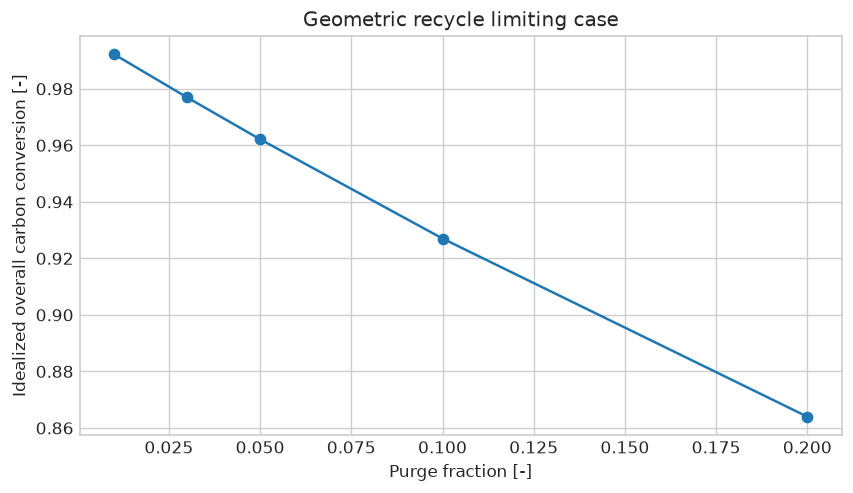

In [17]:
integrated_reactor_inlet = component_moles(
    synthesis_feed_cooler.getOutletStream().getFluid()
)
integrated_reactor_outlet = component_moles(
    integrated_synthesis_reactor.getOutletStream().getFluid()
)
integrated_carbon_oxide_feed = (
    integrated_reactor_inlet["CO"] + integrated_reactor_inlet["CO2"]
)
integrated_methanol_formed = (
    integrated_reactor_outlet["methanol"]
    - integrated_reactor_inlet["methanol"]
)
integrated_single_pass_conversion = (
    integrated_methanol_formed / integrated_carbon_oxide_feed
)
purge_fractions = np.array([0.01, 0.03, 0.05, 0.10, 0.20])
recycle_fractions = 1.0 - purge_fractions
overall_conversions = integrated_single_pass_conversion / (
    1.0 - recycle_fractions * (1.0 - integrated_single_pass_conversion)
)
recycle_table = pd.DataFrame(
    {
        "purge fraction [-]": purge_fractions,
        "recycle fraction [-]": recycle_fractions,
        "idealized overall carbon conversion [-]": overall_conversions,
    }
)

figure, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
axis.plot(purge_fractions, overall_conversions, marker="o")
axis.set_xlabel("Purge fraction [-]")
axis.set_ylabel("Idealized overall carbon conversion [-]")
axis.set_title("Geometric recycle limiting case")
plt.show()

recycle_table

## 17. Process KPIs and carbon routing

The final engineering indicators normalize utility loads by crude-product flow and track carbon from fresh methane to reactor methanol. These values describe only the modeled front end. Fired-reformer fuel, steam generation, oxygen, cooling-water pumping, purge fuel credit, distillation, carbon capture, utilities, and indirect emissions are absent.

Carbon efficiency below unity is expected in a once-through equilibrium screen because carbon remains as methane, carbon monoxide, and carbon dioxide. A rigorous lifecycle calculation needs defined system boundaries and emission factors rather than an invented benchmark.

In [18]:
fresh_carbon_moles = element_totals(
    component_moles(integrated_feed.getFluid())
)["C"]
reactor_methanol_moles = integrated_reactor_outlet["methanol"]
carbon_to_reactor_methanol = reactor_methanol_moles / fresh_carbon_moles
crude_product_rate_kg_per_h = crude_methanol_stream.getFlowRate("kg/hr")
specific_compression_kwh_per_kg = (
    compressor_power_kw / crude_product_rate_kg_per_h
)
specific_reformer_heat_kwh_per_kg = (
    integrated_reformer_duty_kw / crude_product_rate_kg_per_h
)
specific_synthesis_heat_removal_kwh_per_kg = (
    -integrated_synthesis_duty_kw / crude_product_rate_kg_per_h
)

kpi_table = pd.Series(
    {
        "fresh carbon to reactor methanol [-]": carbon_to_reactor_methanol,
        "crude product rate [kg/h]": crude_product_rate_kg_per_h,
        "compression electricity [kWh/kg crude]": (
            specific_compression_kwh_per_kg
        ),
        "reformer heat input [kWh/kg crude]": specific_reformer_heat_kwh_per_kg,
        "synthesis heat removal [kWh/kg crude]": (
            specific_synthesis_heat_removal_kwh_per_kg
        ),
    },
    name="Modeled front-end indicators",
)
kpi_table

fresh carbon to reactor methanol [-]         0.443682
crude product rate [kg/h]                4,495.048163
compression electricity [kWh/kg crude]       0.303229
reformer heat input [kWh/kg crude]           0.338052
synthesis heat removal [kWh/kg crude]        0.086698
Name: Modeled front-end indicators, dtype: float64

## 18. Verification, troubleshooting, and acceptance checks

The assertions cover atom closure, reaction direction, mass balances, phase behavior, monotonic sensitivities, compressor power, product recovery, and recycle limiting behavior.

Troubleshooting guidance:

- Run from the first cell after reconnecting Colab.
- Use exact component names: `methane`, `water`, `hydrogen`, `CO`, `CO2`, and `methanol`.
- Keep tiny product seeds positive and identical across sensitivity cases.
- Do not calculate conversion from mole fractions when total moles change.
- Mark methane inert in the synthesis-only Gibbs reactor.
- Initialize and flash the CPA product fluid before reading phases.
- Inspect phase names and composition instead of assuming phase indices.
- Treat a convergence error or element residual as a failed calculation, not a value to replace with `NaN`.

In [19]:
integrated_reformer_inlet = component_moles(integrated_feed.getFluid())
integrated_reformer_outlet = component_moles(
    integrated_reformer.getOutletStream().getFluid()
)
integrated_reformer_atoms_in = element_totals(integrated_reformer_inlet)
integrated_reformer_atoms_out = element_totals(integrated_reformer_outlet)
integrated_atom_residual = max(
    abs(
        integrated_reformer_atoms_out[element]
        / integrated_reformer_atoms_in[element]
        - 1.0
    )
    for element in integrated_reformer_atoms_in
)
reformer_mass_residual_fraction = abs(
    integrated_reformer.getOutletStream().getFlowRate("kg/hr")
    / integrated_feed.getFlowRate("kg/hr")
    - 1.0
)
water_separator_mass_residual = (
    water_separator.getGasOutStream().getFlowRate("kg/hr")
    + water_separator.getLiquidOutStream().getFlowRate("kg/hr")
    - syngas_cooler.getOutletStream().getFlowRate("kg/hr")
)

checks = {
    "base reformer atom balance closes": max(
        abs(value) for value in smr_element_residuals.values()
    ) < 1.0e-12,
    "base synthesis atom balance closes": max(
        abs(value) for value in synthesis_element_residuals.values()
    ) < 1.0e-12,
    "integrated reformer atom balance closes": integrated_atom_residual < 1.0e-12,
    "reformer mass residual is below 20 ppm": (
        reformer_mass_residual_fraction < 2.0e-5
    ),
    "water separator mass balance closes": abs(
        water_separator_mass_residual
    ) < 1.0e-8,
    "product separator mass balance closes": abs(
        separator_mass_residual_kg_per_h
    ) < 1.0e-8,
    "SMR is endothermic": integrated_reformer_duty_kw > 0.0,
    "methanol synthesis is exothermic": integrated_synthesis_duty_kw < 0.0,
    "reformer conversion rises with temperature": np.all(
        np.diff(reformer_temperature_table["methane conversion [-]"]) > 0.0
    ),
    "reformer conversion rises with steam ratio": np.all(
        np.diff(steam_ratio_table["methane conversion [-]"]) > 0.0
    ),
    "synthesis conversion falls with temperature": np.all(
        np.diff(temperature_conversions) < 0.0
    ),
    "synthesis conversion rises with pressure": np.all(
        np.diff(pressure_conversions) > 0.0
    ),
    "compressor consumes positive power": compressor_power_kw > 0.0,
    "CPA product flash has gas and liquid": (
        cpa_product_fluid.getNumberOfPhases() == 2
    ),
    "crude liquid is methanol rich": crude_methanol_fraction > 0.80,
    "methanol recovery exceeds 95 percent": methanol_recovery > 0.95,
    "recycle limit stays physical": np.all(
        (overall_conversions > integrated_single_pass_conversion)
        & (overall_conversions < 1.0)
    ),
}

assert all(checks.values()), checks
verification_table = pd.Series(checks, name="passed")
verification_table

base reformer atom balance closes              True
base synthesis atom balance closes             True
integrated reformer atom balance closes        True
reformer mass residual is below 20 ppm         True
water separator mass balance closes            True
product separator mass balance closes          True
SMR is endothermic                             True
methanol synthesis is exothermic               True
reformer conversion rises with temperature     True
reformer conversion rises with steam ratio     True
synthesis conversion falls with temperature    True
synthesis conversion rises with pressure       True
compressor consumes positive power             True
CPA product flash has gas and liquid           True
crude liquid is methanol rich                  True
methanol recovery exceeds 95 percent           True
recycle limit stays physical                   True
Name: passed, dtype: bool

## 19. Summary, limitations, exercises, and references

**Summary.** NeqSim's Gibbs reactor solves reaction equilibrium while conserving elements; streams and unit operations connect reforming, cooling, water separation, compression, and synthesis. SRK is used for hot reacting gas, while CPA is selected for methanol-water condensation. The notebook verifies 17 engineering conditions, including atom and mass closure, expected equilibrium trends, positive compressor power, two-phase product separation, methanol-rich crude liquid, and recycle limiting behavior.

**Limitations.** The model omits feed desulfurization, heavier hydrocarbons, furnace combustion, carbon formation, detailed heat integration, catalyst kinetics and deactivation, reactor geometry, pressure drop, by-products, recycle recomputation, purge optimization, distillation, utility systems, equipment sizing, safety analysis, emissions factors, economics, and licensed process knowledge. Gibbs equilibrium is an upper thermodynamic limit, not a production guarantee.

**Further exercises.** (1) Add carbon dioxide to the natural-gas feed. (2) Compare 20 and 30 bara reforming. (3) Build an iterative recycle with a specified purge and recompute equilibrium. (4) Add crude-methanol distillation. (5) Match hot and cold duties in a heat-recovery network. (6) Add fired-duty fuel and direct carbon dioxide emissions. (7) Replace equilibrium with validated kinetics when available.

**Authoritative references.** [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html), [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html), [NeqSim process-design guide](https://equinor.github.io/neqsim/process/process_design_guide), [U.S. Department of Energy natural-gas reforming](https://www.energy.gov/cmei/fuels/hydrogen-production-natural-gas-reforming), and [NIST Chemistry WebBook methanol](https://webbook.nist.gov/cgi/cbook.cgi?ID=C67561&Mask=1F). Standard reaction and process theory follows established chemical-reaction-engineering and process-design texts.

In [20]:
validation_report = {
    "neqsim_version": NEQSIM_VERSION,
    "reformer_methane_conversion": float(smr_conversion),
    "reformer_duty_kw": float(integrated_reformer_duty_kw),
    "synthesis_duty_kw": float(integrated_synthesis_duty_kw),
    "compressor_power_kw": float(compressor_power_kw),
    "crude_methanol_rate_kg_per_h": float(crude_product_rate_kg_per_h),
    "crude_methanol_mole_fraction": float(crude_methanol_fraction),
    "methanol_recovery": float(methanol_recovery),
    "maximum_integrated_atom_residual": float(integrated_atom_residual),
    "checks_passed": int(sum(checks.values())),
    "checks_total": len(checks),
}

print(json.dumps(validation_report, indent=2))

{
  "neqsim_version": "3.16.0",
  "reformer_methane_conversion": 0.792984113708701,
  "reformer_duty_kw": 1519.5599270266484,
  "synthesis_duty_kw": -389.71363314719235,
  "compressor_power_kw": 1363.0270401928183,
  "crude_methanol_rate_kg_per_h": 4495.048162759734,
  "crude_methanol_mole_fraction": 0.8412117061344434,
  "methanol_recovery": 0.9756462721192969,
  "maximum_integrated_atom_residual": 2.220446049250313e-15,
  "checks_passed": 17,
  "checks_total": 17
}
